# US Equities Panel: Feasibility Analysis

`config/setup.yaml` declares a daily long-short strategy over the broad US cross-section:
which stocks are eligible, how often the book turns over, what a round trip costs, how the
sample is split. This notebook asks whether the data supports it, and fits nothing.

## Learning objectives

- Count the tradable universe under the screen the pipeline applies on every decision date,
  and read clearance off an exceedance curve against the declared cost
- Compare a per-share cost assumption with a proportional one across a cross-section whose
  prices span orders of magnitude, and fit the declared folds without touching the holdout

## Book reference

Chapter 6, Sections 6.2-6.6. Reads the equity panel and `config/setup.yaml`, writes nothing.

In [1]:
"""US Equities Panel Case Study - Feasibility Analysis."""

import warnings

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import yaml
from ml4t.diagnostic.splitters.calendar import TradingCalendar

from case_studies.utils.feasibility import exceedance_curve, fold_timeline, panel_acf
from data import load_us_equities
from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "us_equities_panel"
START_DATE = "1990-01-01"
END_DATE = "2018-03-31"  # the archive's last session

## Configuration

Every knob is read from `setup.yaml`, and everything below computes on the development window
alone, so nothing the holdout contains can shape a choice made here. The eligibility
thresholds are the only constants declared locally, since the YAML has no key for them.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
SETUP = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])
HOLDOUT_END = str(SETUP["evaluation"]["holdout_end"])
PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_BUFFER = SETUP["labels"]["buffer"]
LABELS = [PRIMARY_LABEL, *SETUP["labels"]["variants"]]  # fwd_ret_1d, fwd_ret_5d, fwd_ret_21d
HORIZONS = sorted(int(name.rsplit("_", 1)[-1].removesuffix("d")) for name in LABELS)
# Both legs of the widest sort the sweep asks for; breadth under this cannot fill a book.
BREADTH_FLOOR = 2 * max(SETUP["backtest"]["sweep"]["top_k_grid"][PRIMARY_LABEL])
COST_BPS = sum(SETUP["costs"]["per_leg_cost_bps_range"])  # round trip at the declared midpoint
HALF_SPREADS = [c for c in SETUP["backtest"]["sweep"]["cost_grid_half_spread_usd"] if c > 0]
HALF_SPREAD_USD = HALF_SPREADS[len(HALF_SPREADS) // 2]
MIN_PRICE = 5.0  # penny-stock floor, as 02_labels applies it
MIN_ADV_USD = 1_000_000  # dollar volume a position has to be able to hide in
ADV_WINDOW = 21  # sessions of history the liquidity screen averages over
print(
    f"Development {START_DATE} to {HOLDOUT_START} | sealed holdout to {HOLDOUT_END} | "
    f"horizons {HORIZONS} | breadth floor {BREADTH_FLOOR} | round trip {COST_BPS} bps"
)

Development 1990-01-01 to 2016-01-01 | sealed holdout to 2018-03-31 | horizons [1, 5, 21] | breadth floor 100 | round trip 25 bps


## A. Orientation

The archive holds daily bars for every US common stock that traded into the first quarter of
2018, delisted names included up to the session they stopped trading, so a universe formed on
any past date is the universe that existed on it. A cross-sectional strategy takes no view on
the market - it ranks stocks against each other and holds both ends of the ranking - so
breadth matters more than any single name. Three questions decide whether that is worth
building here: does the eligible universe stay wide enough on every decision date, is a
typical move large next to the spread it crosses, and are there enough decision dates to
walk forward without reading the holdout.

## B. Universe and cost feasibility

### B.1 Load and verify the declared universe. The loader returns one row per stock and
session; `adj_close` carries splits and dividends back through the history, so its
differences are returns and the printed `close`'s are not.

In [4]:
panel = load_us_equities(start_date=START_DATE, end_date=END_DATE)
research = panel.filter(pl.col("timestamp") < pl.lit(HOLDOUT_START).str.to_date()).sort(
    ["symbol", "timestamp"]
)

n_declared = SETUP["universe"]["n_assets"]
assert panel["symbol"].n_unique() <= n_declared, "the panel holds more stocks than setup.yaml"
print(
    f"{panel['symbol'].n_unique():,} stocks against {n_declared:,} declared | development "
    f"window {research['symbol'].n_unique():,} stocks, {len(research):,} bars, "
    f"{research['timestamp'].n_unique():,} dates to {research['timestamp'].max()}"
)

3,199 stocks against 3,199 declared | development window 3,175 stocks, 13,020,703 bars, 6,672 dates to 2015-12-31


### B.2 Breadth at every decision date

The strategy decides at every close, so what matters is how many stocks pass the eligibility
screen on each of them, not how many the archive holds in total. A stock qualifies when it
trades above the penny-stock floor and its dollar volume clears the liquidity threshold, both
read from the session itself - screening over the full sample would admit stocks on dates
nobody could have known they would qualify on.

In [5]:
dollar_volume = (pl.col("adj_close") * pl.col("adj_volume")).rolling_mean(ADV_WINDOW)
breadth = (
    research.with_columns(dollar_volume.over("symbol").alias("adv"))
    .drop_nulls("adv")
    .group_by("timestamp")
    .agg(
        ((pl.col("adj_close") > MIN_PRICE) & (pl.col("adv") > MIN_ADV_USD))
        .sum()
        .alias("n_eligible")
    )
    .sort("timestamp")
)

# A decision date is a session the declared calendar holds, and the archive carries stray
# prints on dates it does not. `get_sessions` maps a timestamp forward to the session settling
# it, so a date mapping to itself is one the exchange held.
sessions = pl.Series(
    TradingCalendar(SETUP["evaluation"]["calendar"])
    .get_sessions(pd.DatetimeIndex(breadth["timestamp"].to_list(), tz="UTC"))
    .to_numpy()
).cast(pl.Date)
breadth = breadth.with_columns((sessions == pl.col("timestamp")).alias("is_session"))
decisions = breadth.filter("is_session")

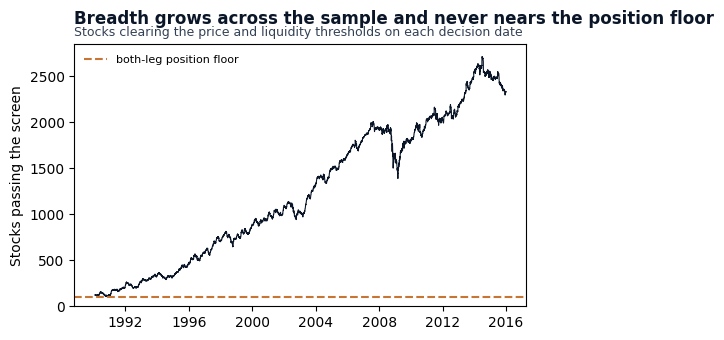

In [6]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.plot(decisions["timestamp"], decisions["n_eligible"], color=COLORS["blue"], linewidth=0.8)
ax.axhline(BREADTH_FLOOR, color=COLORS["copper"], ls="--", lw=1.5, label="both-leg position floor")
ax.set_ylabel("Stocks passing the screen")
ax.set_ylim(0, None)
ax.legend(frameon=False, fontsize=8, loc="upper left")
add_message_title(
    ax,
    "Breadth grows across the sample and never nears the position floor",
    subtitle="Stocks clearing the price and liquidity thresholds on each decision date",
)
plt.show()

### B.3 What a round trip costs

`setup.yaml::costs` prices a trade as a fraction of what it moves, and carries a per-share
half-spread as a companion regime. The two disagree across this cross-section, since a fixed
number of cents is a different fraction of a single-digit stock than of one in the hundreds.

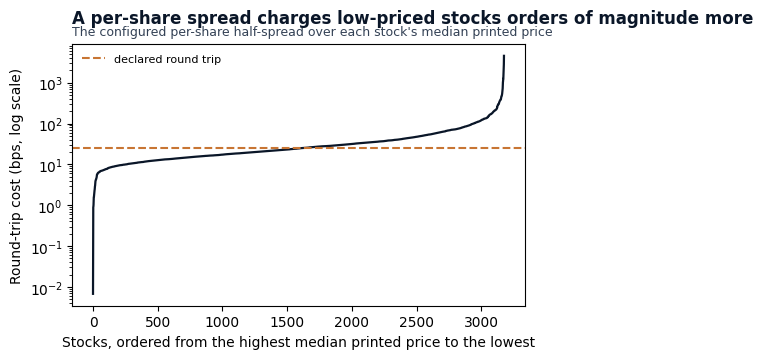

In [7]:
cost = (
    research.group_by("symbol")
    .agg(pl.col("close").median().alias("price"))
    .drop_nulls("price")
    .with_columns((2 * HALF_SPREAD_USD / pl.col("price") * 1e4).alias("per_share_bps"))
    .sort("per_share_bps")
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.plot(range(len(cost)), cost["per_share_bps"], color=COLORS["blue"], lw=1.6)
ax.axhline(COST_BPS, color=COLORS["copper"], ls="--", lw=1.5, label="declared round trip")
ax.set_yscale("log")
ax.set_xlabel("Stocks, ordered from the highest median printed price to the lowest")
ax.set_ylabel("Round-trip cost (bps, log scale)")
ax.legend(frameon=False, fontsize=8, loc="upper left")
add_message_title(
    ax,
    "A per-share spread charges low-priced stocks orders of magnitude more",
    subtitle="The configured per-share half-spread over each stock's median printed price",
)
plt.show()

That spread is why `setup.yaml::costs.model` prices in basis points: one proportional number
is wrong for every stock by a bounded amount, where one per-share number is wrong for the
cheap end by orders of magnitude. Moves are compared against it at each label horizon.

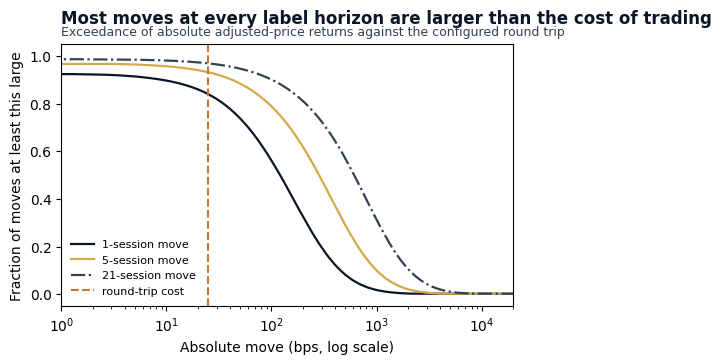

In [8]:
returns = research.with_columns(
    pl.col("adj_close").pct_change(h).abs().over("symbol").alias(f"h{h}") for h in HORIZONS
)

styles = ((COLORS["blue"], "-"), (COLORS["amber"], "-"), (COLORS["neutral"], "-."))
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for h, (color, ls) in zip(HORIZONS, styles, strict=True):
    magnitude, fraction = exceedance_curve(returns[f"h{h}"].drop_nulls().to_numpy() * 1e4)
    ax.plot(magnitude, fraction, color=color, ls=ls, lw=1.6, label=f"{h}-session move")
ax.axvline(COST_BPS, color=COLORS["copper"], ls="--", lw=1.5, label="round-trip cost")
ax.set_xscale("log")
ax.set_xlim(1, 2e4)
ax.set_xlabel("Absolute move (bps, log scale)")
ax.set_ylabel("Fraction of moves at least this large")
ax.legend(frameon=False, fontsize=8, loc="lower left")
add_message_title(
    ax,
    "Most moves at every label horizon are larger than the cost of trading",
    subtitle="Exceedance of absolute adjusted-price returns against the configured round trip",
)
plt.show()

### B.4 How long what the strategy reads stays put

Rebalancing daily is only worth the turnover if a stock's recent behaviour says something
about the session ahead. The cheapest version is whether its own return predicts its next,
computed inside each stock and pooled - stacking thousands and correlating measures the joins.

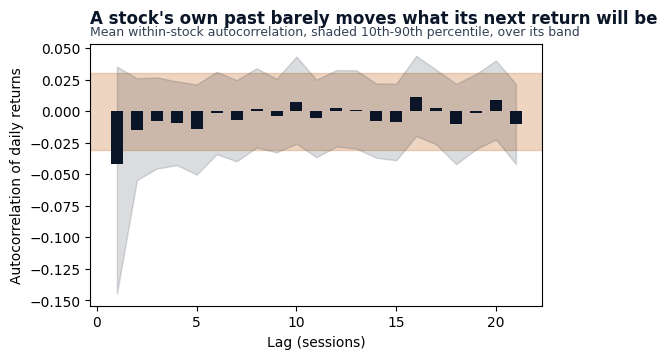

In [9]:
acf = panel_acf(
    research.with_columns(pl.col("adj_close").pct_change().over("symbol").alias("ret")),
    entity_col="symbol",
    value_col="ret",
    max_lags=max(HORIZONS),
    min_obs=252,  # a stock contributes a curve only with a year of sessions behind it
).filter(pl.col("lag") > 0)  # lag zero is one by construction and only rescales the axis

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.axhspan(-acf["band"][0], acf["band"][0], color=COLORS["copper"], alpha=0.3, zorder=0)
ax.fill_between(acf["lag"], acf["acf_p10"], acf["acf_p90"], color=COLORS["blue"], alpha=0.15)
ax.bar(acf["lag"], acf["acf"], color=COLORS["blue"], width=0.6, zorder=2)
ax.set_xlabel("Lag (sessions)")
ax.set_ylabel("Autocorrelation of daily returns")
add_message_title(
    ax,
    "A stock's own past barely moves what its next return will be",
    subtitle="Mean within-stock autocorrelation, shaded 10th-90th percentile, over its band",
)
plt.show()

The bars sit close to zero against the spread of the per-stock curves behind them, so what
the strategy ranks on has to come from the cross-section - one stock against the others on
the same date - which `mapping.class` builds and the feature notebooks supply.

### B.5 Move scale against cost

The ratio divides the median absolute move at the primary horizon by the declared round trip,
and the clearance share counts the moves above it. Neither says total cost clears: both legs
of the book pay, borrow accrues on the short leg, and a move is a magnitude with no direction.

In [10]:
move_bps = returns[f"h{HORIZONS[0]}"].drop_nulls() * 1e4
per_share = cost["per_share_bps"]
print(
    f"Per-share round trip {per_share.min():.2f} to {per_share.max():.0f} bps, median "
    f"{per_share.median():.1f} bps | median {HORIZONS[0]}-session move {move_bps.median():.0f} "
    f"bps, ratio {move_bps.median() / COST_BPS:.1f}x, share over the round trip "
    f"{(move_bps > COST_BPS).mean():.3f}"
)

Per-share round trip 0.01 to 4545 bps, median 24.5 bps | median 1-session move 121 bps, ratio 4.8x, share over the round trip 0.841


The median absolute one-session move is 121 bps against a declared round trip of 25 bps, a
ratio of 4.8x, and 0.841 of one-session moves are larger than the round trip. The same
per-share half-spread costs 0.01 bps on the highest-priced stock in the panel and 4545 bps on
the lowest, with a median of 24.5 bps.

## C. Design decisions

### C.1 Cadence

`setup.yaml::decision.cadence` snapshots at the close and executes at the next open, which
B.3 supports; B.4 is why the ranking is labelled at two longer horizons as well.

### C.2 Kill conditions

Four thresholds in `setup.yaml::kill_conditions` send the strategy back to the drawing board,
each tested where the evidence exists rather than here: a cross-sectional information
coefficient below its floor across every feature, a net-Sharpe-to-cost ratio under its floor,
alpha concentrated in the least liquid quintile, and net Sharpe after borrow under its own.

### C.3 Mapping class

`setup.yaml::mapping.class` sorts stocks into deciles and holds the top against the bottom,
equally weighted inside each, because the bottom of a ranking carries as much information as
the top. Equal weighting keeps the comparison about the ranking, and the allocation stage
sweeps the alternatives separately.

## D. Walk-forward structure

### D.1 Effective sample size. What evaluation spends is decision dates, not rows: a wider
cross-section on one date buys precision, not independence.

In [11]:
eligible_per_date = decisions["n_eligible"]
print(
    f"Decision dates {len(decisions):,} of {len(breadth):,} dated in the archive | eligible "
    f"stocks per decision date {eligible_per_date.mean():.0f} on average, "
    f"{eligible_per_date.min():,} at the fewest and {eligible_per_date.max():,} at the widest, "
    f"under the floor on {(eligible_per_date < BREADTH_FLOOR).sum()} of them"
)

Decision dates 6,533 of 6,651 dated in the archive | eligible stocks per decision date 1234 on average, 103 at the fewest and 2,717 at the widest, under the floor on 0 of them


### D.2 Fold demonstration

`generate_cv_splits` derives the folds from `setup.yaml::evaluation` alone, rolling back from
the holdout so the most recent fold is the first generated. Between each training and
validation block sits a purge gap the width of the label horizon, stopping a label computed
inside training from resolving inside validation. The figure draws those boundaries, so it
and the folds agree by construction.

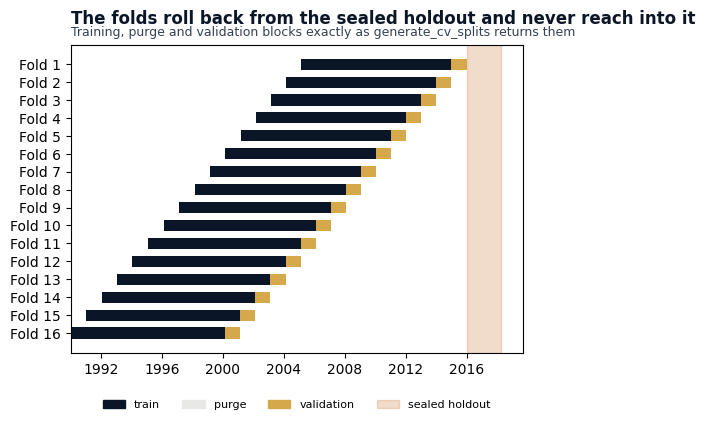

In [12]:
splits = generate_cv_splits(
    research.select("timestamp"),
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
    date_col="timestamp",
)
last_val = max(s["val_end"] for s in splits)
assert len(splits) == SETUP["evaluation"]["n_splits"], "fold count differs from setup.yaml"
assert str(last_val.date()) < HOLDOUT_START, "a fold reaches into the holdout"

fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
fold_timeline(ax, splits, holdout=(HOLDOUT_START, HOLDOUT_END))
add_message_title(
    ax,
    "The folds roll back from the sealed holdout and never reach into it",
    subtitle="Training, purge and validation blocks exactly as generate_cv_splits returns them",
)
plt.show()

## E. Derived artifacts. Nothing: the eligibility screen is a rule rather than a table, which
`02_labels` re-applies at each decision date from the same thresholds.

## F. Findings vs `setup.yaml`

| Knob | Evidence | Revise it when |
|---|---|---|
| `universe.n_assets` | B.1 count, B.2 breadth | eligible breadth falls under what both legs of the sort need |
| `costs.model` | B.3 per-share cost across the cross-section | per-stock quotes replace the assumption, or prices stop spanning orders of magnitude |
| `decision.cadence` | B.3 exceedance, B.4 persistence | moves stop clearing the round trip at the primary horizon |
| `labels.primary` | B.5 ratio at each horizon | a longer horizon buys more than the turnover it saves |
| `evaluation.n_splits` | D.1 decision dates, D.2 boundaries | the folds no longer fit ahead of the holdout |

In [13]:
print(
    f"universe.n_assets {SETUP['universe']['n_assets']}, eligible per decision date "
    f"{eligible_per_date.min():,} to {eligible_per_date.max():,} | costs.model "
    f"{SETUP['costs']['model']}, round trip {COST_BPS} bps | decision.cadence "
    f"{SETUP['decision']['cadence']} | labels.primary {PRIMARY_LABEL}\n"
    f"evaluation.n_splits {SETUP['evaluation']['n_splits']}, generated {len(splits)}, "
    f"last validation ends {last_val.date()}, holdout untouched"
)

universe.n_assets 3199, eligible per decision date 103 to 2,717 | costs.model percentage, round trip 25 bps | decision.cadence daily_close | labels.primary fwd_ret_1d
evaluation.n_splits 16, generated 16, last validation ends 2015-12-30, holdout untouched


Eligible breadth runs from 103 stocks at its narrowest to 2,717 at its widest against a floor
of 100, and no decision date falls under that floor. Sixteen folds are generated from the
declared design, the most recent validation ending 2015-12-30, and the holdout is untouched.

## Key takeaways

1. **Count the universe under the screen the pipeline applies, on every decision date.** A
   total drawn from the whole archive counts stocks that were not tradable when the strategy
   would have acted, and a date the exchange closed is not a decision date.
2. **Take returns from the adjusted series, never the printed one**, where a split shows up
   as a move of tens of percent.
3. **Check a per-share cost assumption against the price distribution before adopting it**,
   because a fixed number of cents is a different fraction of every stock.
4. **Compute a panel autocorrelation inside each entity, never across the stack**, or it
   measures where one stock's history is glued to the next one's.

### Known limitations

- The archive ends in the first quarter of 2018, so there is nothing more recent than the
  declared holdout to test on.
- Cost is one proportional assumption applied to every stock and date; quotes at panel scale
  would let it vary by name and era, and the cost stage sweeps a grid instead.
- Borrow on the short leg is a flat annual assumption, neither flat across names nor stable.

**Next**: labels at the declared horizons, built on this development window.